# Import Library

In [86]:
import os
import cv2
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

from datetime import datetime
from collections import Counter
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, matthews_corrcoef
)

import lightgbm as lgb
from sklearn.svm import SVC

In [2]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Import Data

In [3]:
DIR = r"C:\Users\Nettaanell D\Documents\Assigment\Project\Data Engineer\Daun Nilam\data_all"

def load_image_paths_and_labels(dir_root):
    X_paths = []
    y_labels = []
    for root, dirs, files in os.walk(dir_root):
        for f in files:
            if f.startswith('.') or 'DS_Store' in f:
                continue
            full = os.path.join(root, f)
            rel = os.path.relpath(root, dir_root)
            if rel == '.' or rel == '':
                label = 'unknown'
            else:
                label = rel.replace('\\','/')
            X_paths.append(full)
            y_labels.append(label)
    class_names = sorted(list(set(y_labels)))
    return X_paths, y_labels, class_names


In [4]:
X_paths, y_labels, class_names = load_image_paths_and_labels(DIR)

print("Total gambar:", len(X_paths))
print("Jumlah kelas:", len(class_names))
print("Contoh kelas:", class_names[:10])
print("Distribusi:", Counter(y_labels))

Total gambar: 179
Jumlah kelas: 2
Contoh kelas: ['nilamHT', 'nilamSK']
Distribusi: Counter({'nilamHT': 97, 'nilamSK': 82})


# Helper Function 

## for read & prepare image to the MobileNetV2 process

## Change Label to Integer

In [6]:
le = LabelEncoder()
y_int = le.fit_transform(y_labels)
print("Label Mapping:", dict(zip(le.classes_, range(len(le.classes_)))))

Label Mapping: {np.str_('nilamHT'): 0, np.str_('nilamSK'): 1}


## Split Data

In [7]:
test_size = 0.05
val_size = 0.05

X_paths_trainval, X_paths_test, y_trainval, y_test = train_test_split(
    X_paths, y_int, test_size=test_size, random_state=RANDOM_STATE, stratify=y_int
)

#split trainval -> train + val
val_fraction_of_trainval = val_size/ (1.0 - test_size)

X_paths_train, X_paths_val, y_train, y_val = train_test_split(
    X_paths_trainval, y_trainval, test_size=val_fraction_of_trainval,
    random_state=RANDOM_STATE, stratify=y_trainval
)

print("Counts -> train:", len(X_paths_train), "Val:", len(X_paths_val), "test:", len(X_paths_test))
print("Class Distribution Train:", Counter(y_train))

Counts -> train: 161 Val: 9 test: 9
Class Distribution Train: Counter({np.int64(0): 87, np.int64(1): 74})


## Feature Extraction(MobileNetV2)

In [ ]:
print("Memuat MobileNetV2...")
base_model = MobileNetV2(
    include_top=False,
    weights='imagenet',
    pooling='avg',
    input_shape=(224, 224, 3)
)
base_model.trainable = False
print("MobileNetV2 siap. Output shape:", base_model.output_shape)

Memuat MobileNetV2...
MobileNetV2 siap. Output shape: (None, 1280)


In [ ]:
def extract_features_mobilenet(paths, labels, model, batch_size=64, verbose=1):
    """
    Parameters
    ----------
    paths      : list of str  — path gambar
    labels     : array-like   — label integer bersesuaian
    model      : tf.keras.Model — model feature extractor yang sudah dibuat
    batch_size : int
    verbose    : int (0/1)

    Returns
    -------
    features       : np.ndarray shape (N_valid, D)
    valid_labels   : np.ndarray shape (N_valid,)
    failures       : list of str — path yang gagal
    """
    valid_imgs   = []
    valid_labels = []
    failures     = []

    for i, (p, lbl) in enumerate(zip(paths, labels)):
        img = cv2.imread(p)
        if img is None:
            failures.append(p)
            continue  
        try:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (224, 224))
            arr = mobilenet_preprocess(img.astype('float32'))
            valid_imgs.append(arr)
            valid_labels.append(lbl)
        except Exception as e:
            failures.append((p, str(e)))

    if len(valid_imgs) == 0:
        raise ValueError("Tidak ada gambar yang berhasil di-load. Periksa path direktori.")

    all_imgs = np.array(valid_imgs, dtype='float32')
    features = model.predict(all_imgs, batch_size=batch_size, verbose=verbose)

    if verbose:
        print(f"  Berhasil  : {len(valid_imgs)} gambar")
        print(f"  Gagal     : {len(failures)} gambar")
        print(f"  Shape fitur: {features.shape}")

    return features, np.array(valid_labels), failures

In [50]:
print("=== Ekstraksi Fitur Train ===")
X_train_feat, y_train, fail_train = extract_features_mobilenet(
    X_paths_train, y_train, base_model, batch_size=64
)

print("\n=== Ekstraksi Fitur Validasi ===")
X_val_feat, y_val, fail_val = extract_features_mobilenet(
    X_paths_val, y_val, base_model, batch_size=64
)

print("\n=== Ekstraksi Fitur Test ===")
X_test_feat, y_test, fail_test = extract_features_mobilenet(
    X_paths_test, y_test, base_model, batch_size=64
)

=== Ekstraksi Fitur Train ===
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 762ms/step
  Berhasil  : 161 gambar
  Gagal     : 0 gambar
  Shape fitur: (161, 1280)

=== Ekstraksi Fitur Validasi ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 239ms/step
  Berhasil  : 9 gambar
  Gagal     : 0 gambar
  Shape fitur: (9, 1280)

=== Ekstraksi Fitur Test ===
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 232ms/step
  Berhasil  : 9 gambar
  Gagal     : 0 gambar
  Shape fitur: (9, 1280)


## Feature Extraction Results

### Shape of extracted Features

In [51]:
print("Shape of extracted features:")
print("Train Set\t :", X_train_feat.shape)
print("Validation Set\t : ", X_val_feat.shape)
print("Test Set\t :", X_test_feat.shape)
print("\nDimensionality of each feature vector:", X_train_feat.shape[1])

Shape of extracted features:
Train Set	 : (161, 1280)
Validation Set	 :  (9, 1280)
Test Set	 : (9, 1280)

Dimensionality of each feature vector: 1280


In [57]:
train_mean = np.mean(X_train_feat)
train_std  = np.std(X_train_feat)
print("\nFeature statistics (training set):")
print(f"Mean : {train_mean:.4f}")
print(f"Std  : {train_std:.4f}")


Feature statistics (training set):
Mean : 0.4070
Std  : 0.6841


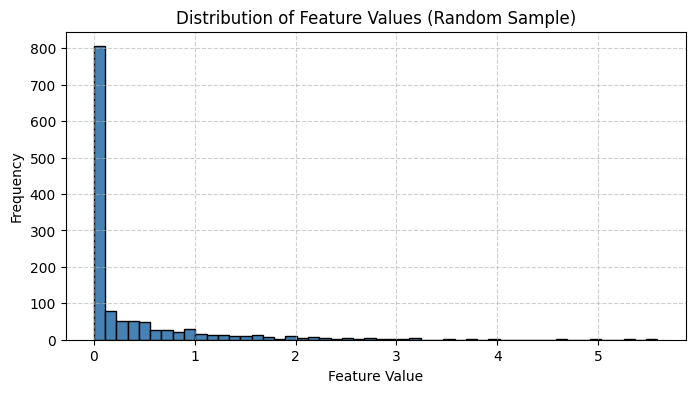

In [70]:
idx = np.random.randint(0, X_train_feat.shape[0])
plt.figure(figsize=(8,4))
plt.hist(X_train_feat[idx], bins=50, color='steelblue', edgecolor='black')
plt.title("Distribution of Feature Values (Random Sample)")
plt.xlabel("Feature Value")
plt.ylabel("Frequency")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

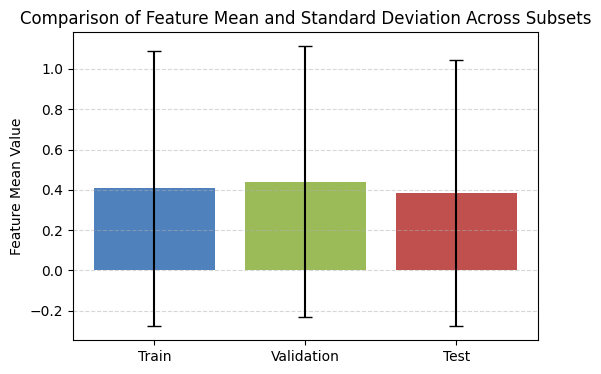

In [72]:
means = [np.mean(X_train_feat), np.mean(X_val_feat), np.mean(X_test_feat)]
stds  = [np.std(X_train_feat), np.std(X_val_feat), np.std(X_test_feat)]
labels = ['Train', 'Validation', 'Test']

plt.figure(figsize=(6,4))
plt.bar(labels, means, yerr=stds, color=['#4F81BD','#9BBB59','#C0504D'], capsize=5)
plt.title("Comparison of Feature Mean and Standard Deviation Across Subsets")
plt.ylabel("Feature Mean Value")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# Model

## LightGBM (Default)

In [73]:
n_classes = len(np.unique(y_train))
print(f"Jumlah kelas terdeteksi: {n_classes}")
print(f"Nama kelas             : {le.classes_}")

if n_classes == 2:
    objective  = 'binary'
    metric     = 'binary_error'
    print("Mode: Binary Classification")
else:
    objective  = 'multiclass'
    metric     = 'multi_error'
    print("Mode: Multiclass Classification")

params = {
    'objective' : objective,
    'metric'    : metric,
    'verbosity' : 1,
    'seed'      : RANDOM_STATE
}

if n_classes > 2:
    params['num_class'] = n_classes

print("\nParameter LightGBM:")
for k, v in params.items():
    print(f"  {k}: {v}")

Jumlah kelas terdeteksi: 2
Nama kelas             : ['nilamHT' 'nilamSK']
Mode: Binary Classification

Parameter LightGBM:
  objective: binary
  metric: binary_error
  verbosity: 1
  seed: 42


In [74]:
train_data = lgb.Dataset(X_train_feat, label=y_train)
valid_data = lgb.Dataset(X_val_feat,   label=y_val, reference=train_data)

evals_result = {}

model = lgb.train(
    params,
    train_data,
    valid_sets=[train_data, valid_data],
    valid_names=['train', 'valid'],
    num_boost_round=100,
    callbacks=[
        lgb.record_evaluation(evals_result),
        lgb.log_evaluation(period=10) 
    ]
)

metric_key = list(evals_result['train'].keys())[0]
print(f"\nMetric yang digunakan: {metric_key}")

train_acc = [1 - e for e in evals_result['train'][metric_key]]
valid_acc = [1 - e for e in evals_result['valid'][metric_key]]

[LightGBM] [Info] Number of positive: 74, number of negative: 87
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.025446 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 49345
[LightGBM] [Info] Number of data points in the train set: 161, number of used features: 1260
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.459627 -> initscore=-0.161843
[LightGBM] [Info] Start training from score -0.161843
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

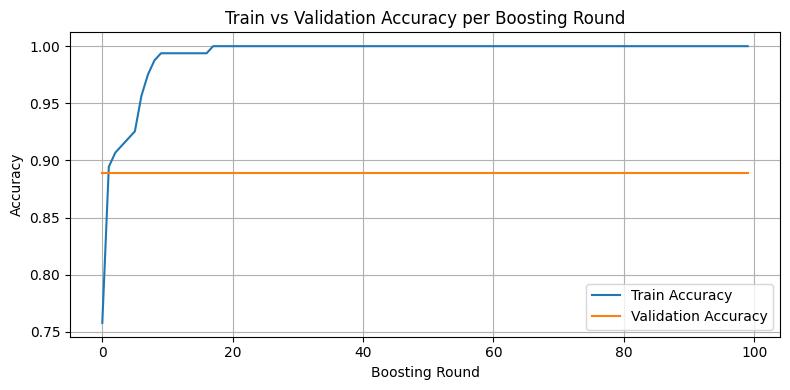

In [75]:
plt.figure(figsize=(8, 4))
plt.plot(train_acc, label='Train Accuracy')
plt.plot(valid_acc, label='Validation Accuracy')
plt.xlabel('Boosting Round')
plt.ylabel('Accuracy')
plt.title('Train vs Validation Accuracy per Boosting Round')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [77]:
y_test_pred_raw = model.predict(X_test_feat)

if y_test_pred_raw.ndim == 1:
    y_test_pred_labels = (y_test_pred_raw >= 0.5).astype(int)
else:
    y_test_pred_labels = np.argmax(y_test_pred_raw, axis=1)

acc_test  = accuracy_score(y_test, y_test_pred_labels)
prec_test = precision_score(y_test, y_test_pred_labels, average='weighted', zero_division=0)
rec_test  = recall_score(y_test,    y_test_pred_labels, average='weighted', zero_division=0)
f1_test   = f1_score(y_test,        y_test_pred_labels, average='weighted', zero_division=0)
mcc_test  = matthews_corrcoef(y_test, y_test_pred_labels)

print("====== Evaluasi pada Data Test ======")
print(f"  Accuracy           : {acc_test:.4f}")
print(f"  Precision (w-avg)  : {prec_test:.4f}")
print(f"  Recall    (w-avg)  : {rec_test:.4f}")
print(f"  F1-Score  (w-avg)  : {f1_test:.4f}")
print(f"  MCC                : {mcc_test:.4f}")

print("\n====== Laporan Klasifikasi ======")
print(classification_report(
    y_test,
    y_test_pred_labels,
    target_names=le.classes_
))

====== Evaluasi pada Data Test ======
  Accuracy           : 0.8889
  Precision (w-avg)  : 0.9111
  Recall    (w-avg)  : 0.8889
  F1-Score  (w-avg)  : 0.8889
  MCC                : 0.8000

====== Laporan Klasifikasi ======
              precision    recall  f1-score   support

     nilamHT       1.00      0.80      0.89         5
     nilamSK       0.80      1.00      0.89         4

    accuracy                           0.89         9
   macro avg       0.90      0.90      0.89         9
weighted avg       0.91      0.89      0.89         9



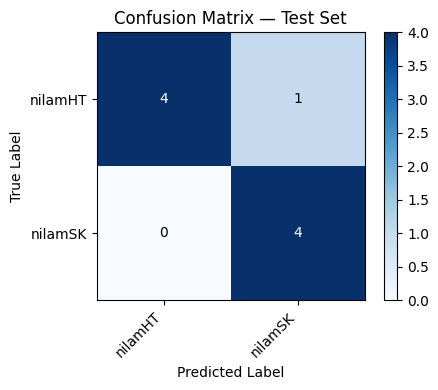

In [78]:
cm = confusion_matrix(y_test, y_test_pred_labels)

fig, ax = plt.subplots(figsize=(max(5, n_classes * 1.5), max(4, n_classes * 1.2)))
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax)

ax.set_xticks(range(n_classes))
ax.set_yticks(range(n_classes))
ax.set_xticklabels(le.classes_, rotation=45, ha='right')
ax.set_yticklabels(le.classes_)

thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, str(cm[i, j]),
                ha='center', va='center',
                color='white' if cm[i, j] > thresh else 'black')

ax.set_ylabel('True Label')
ax.set_xlabel('Predicted Label')
ax.set_title('Confusion Matrix — Test Set')
plt.tight_layout()
plt.show()

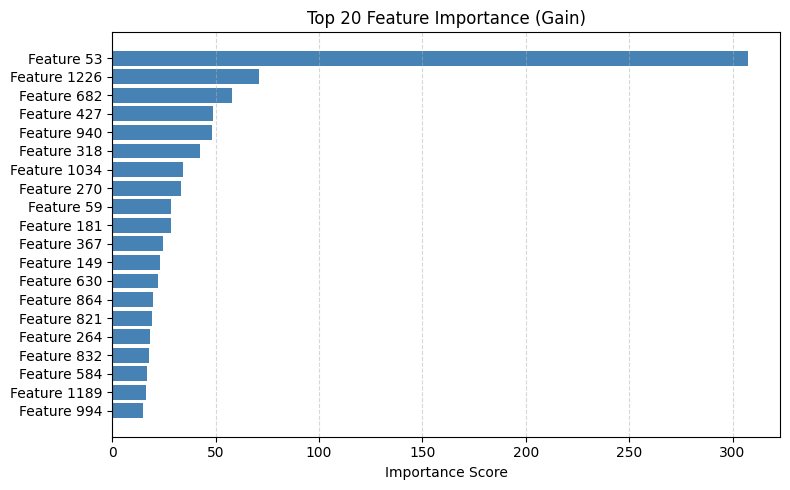

In [81]:
importance = model.feature_importance(importance_type='gain')
top_n      = 20
top_idx    = np.argsort(importance)[::-1][:top_n]

plt.figure(figsize=(8, 5))
plt.barh(
    [f'Feature {i}' for i in top_idx[::-1]],
    importance[top_idx[::-1]],
    color='steelblue'
)
plt.title(f'Top {top_n} Feature Importance (Gain)')
plt.xlabel('Importance Score')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [84]:
y_train_pred_raw = model.predict(X_train_feat)
if y_train_pred_raw.ndim == 1:
    y_train_pred_labels = (y_train_pred_raw >= 0.5).astype(int)
else:
    y_train_pred_labels = np.argmax(y_train_pred_raw, axis=1)
acc_train_final = accuracy_score(y_train, y_train_pred_labels)

y_val_pred_raw = model.predict(X_val_feat)
if y_val_pred_raw.ndim == 1:
    y_val_pred_labels = (y_val_pred_raw >= 0.5).astype(int)
else:
    y_val_pred_labels = np.argmax(y_val_pred_raw, axis=1)
acc_val_final = accuracy_score(y_val, y_val_pred_labels)

print(f"Akurasi Train      : {acc_train_final:.4f} ({acc_train_final*100:.2f}%)")
print(f"Akurasi Validasi   : {acc_val_final:.4f} ({acc_val_final*100:.2f}%)")
print(f"Akurasi Test       : {acc_test:.4f} ({acc_test*100:.2f}%)")

gap_train_val  = acc_train_final - acc_val_final
gap_train_test = acc_train_final - acc_test
print(f"\nGap Train - Validasi : {gap_train_val:+.4f}")
print(f"Gap Train - Test     : {gap_train_test:+.4f}")
if gap_train_test > 0.05:
    print("  Indikasi overfitting: gap Train-Test > 5%")
elif gap_train_test < 0.0:
    print("  Model generalisasi sangat baik")
else:
    print("  Model generalisasi dalam batas wajar")

Akurasi Train      : 1.0000 (100.00%)
Akurasi Validasi   : 0.8889 (88.89%)
Akurasi Test       : 0.8889 (88.89%)

Gap Train - Validasi : +0.1111
Gap Train - Test     : +0.1111
  Indikasi overfitting: gap Train-Test > 5%


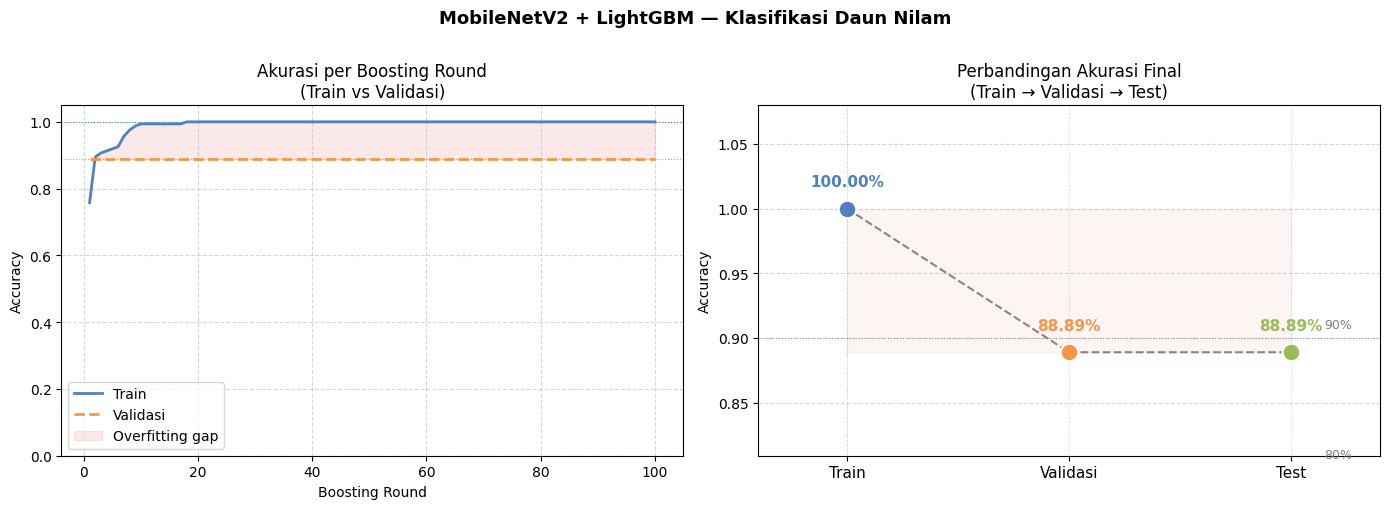

Grafik tersimpan: accuracy_comparison.png


In [85]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
rounds = range(1, len(train_acc) + 1)

ax1.plot(rounds, train_acc, label='Train',    color='#4F81BD', linewidth=2)
ax1.plot(rounds, valid_acc, label='Validasi', color='#F79646', linewidth=2, linestyle='--')

ax1.axhline(y=acc_train_final, color='#4F81BD', linewidth=0.8, linestyle=':')
ax1.axhline(y=acc_val_final,   color='#F79646', linewidth=0.8, linestyle=':')

ax1.fill_between(rounds, train_acc, valid_acc,
                 where=[t > v for t, v in zip(train_acc, valid_acc)],
                 alpha=0.12, color='#E24B4A', label='Overfitting gap')

ax1.set_title('Akurasi per Boosting Round\n(Train vs Validasi)', fontsize=12)
ax1.set_xlabel('Boosting Round')
ax1.set_ylabel('Accuracy')
ax1.set_ylim(0, 1.05)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

ax2 = axes[1]

subsets = ['Train', 'Validasi', 'Test']
accs    = [acc_train_final, acc_val_final, acc_test]
colors  = ['#4F81BD', '#F79646', '#9BBB59']
x_pos   = [0, 1, 2]

ax2.plot(x_pos, accs, color='#888780', linewidth=1.5,
         linestyle='--', zorder=1)

for xi, acc, label, color in zip(x_pos, accs, subsets, colors):
    ax2.scatter(xi, acc, color=color, s=160, zorder=3,
                edgecolors='white', linewidths=1.5)

    ax2.annotate(
        f'{acc*100:.2f}%',
        xy=(xi, acc),
        xytext=(0, 14),
        textcoords='offset points',
        ha='center', va='bottom',
        fontsize=11, fontweight='bold', color=color
    )

    ax2.axvline(x=xi, color=color, linewidth=0.7,
                linestyle=':', alpha=0.5)

for ref_val, ref_lbl in [(0.8, '80%'), (0.9, '90%')]:
    ax2.axhline(y=ref_val, color='gray', linewidth=0.8,
                linestyle=':', alpha=0.7)
    ax2.text(2.15, ref_val + 0.005, ref_lbl,
             fontsize=9, color='gray', va='bottom')

ax2.fill_between(
    [0, 2], [acc_train_final, acc_train_final], [acc_test, acc_test],
    alpha=0.06, color='#E24B4A'
)

ax2.set_xticks(x_pos)
ax2.set_xticklabels(subsets, fontsize=11)
ax2.set_xlim(-0.4, 2.4)
ax2.set_ylim(min(accs) - 0.08, 1.08)
ax2.set_title('Perbandingan Akurasi Final\n(Train → Validasi → Test)', fontsize=12)
ax2.set_ylabel('Accuracy')
ax2.grid(axis='y', linestyle='--', alpha=0.5)

plt.suptitle(
    'MobileNetV2 + LightGBM — Klasifikasi Daun Nilam',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik tersimpan: accuracy_comparison.png")

# Hyperparameter Tuning

| # | Strategi | Parameter Kunci | Tujuan |
|---|---|---|---|
| 1 | **Batasi kompleksitas pohon** | `num_leaves`, `max_depth`, `min_child_samples` | Cegah pohon terlalu dalam menghafal noise |
| 2 | **Regularisasi L1 & L2** | `lambda_l1`, `lambda_l2` | Penalti bobot besar agar model tidak terlalu spesifik |
| 3 | **Subsampling** | `subsample`, `colsample_bytree` | Setiap round hanya lihat sebagian data & fitur — reduksi variance |
| 4 | **Learning rate + early stopping** | `learning_rate`, `early_stopping_rounds` | Belajar lebih hati-hati dan berhenti sebelum overfit |

In [87]:
experiment_results = []

def run_experiment(name, params, num_boost_round=300,
                   early_stopping_rounds=30, verbose_eval=50):
    """
    Parameters
    ----------
    name                 : str  — nama eksperimen
    params               : dict — hyperparameter LightGBM
    num_boost_round      : int  — maksimum boosting round
    early_stopping_rounds: int  — berhenti jika validasi tidak
                                  membaik selama N round
    verbose_eval         : int  — frekuensi cetak log

    Returns
    -------
    dict berisi semua metrik dan kurva akurasi
    """
    print(f"\n{'='*60}")
    print(f"  Eksperimen : {name}")
    print(f"{'='*60}")

    p = {
        'objective' : 'binary',
        'metric'    : 'binary_error',
        'verbosity' : -1,
        'seed'      : RANDOM_STATE
    }
    p.update(params)

    _train_data = lgb.Dataset(X_train_feat, label=y_train)
    _valid_data = lgb.Dataset(X_val_feat,   label=y_val, reference=_train_data)

    _evals = {}
    callbacks = [
        lgb.record_evaluation(_evals),
        lgb.log_evaluation(period=verbose_eval),
        lgb.early_stopping(stopping_rounds=early_stopping_rounds, verbose=True)
    ]

    mdl = lgb.train(
        p, _train_data,
        valid_sets=[_train_data, _valid_data],
        valid_names=['train', 'valid'],
        num_boost_round=num_boost_round,
        callbacks=callbacks
    )

    metric_key = list(_evals['train'].keys())[0]
    tr_acc  = [1 - e for e in _evals['train'][metric_key]]
    val_acc = [1 - e for e in _evals['valid'][metric_key]]

    pred_prob = mdl.predict(X_test_feat)
    pred_lbl  = (pred_prob >= 0.5).astype(int)

    tr_prob  = mdl.predict(X_train_feat)
    tr_lbl   = (tr_prob  >= 0.5).astype(int)
    val_prob = mdl.predict(X_val_feat)
    val_lbl  = (val_prob  >= 0.5).astype(int)

    result = {
        'name'           : name,
        'params'         : p,
        'best_round'     : mdl.best_iteration,
        'acc_train'      : accuracy_score(y_train, tr_lbl),
        'acc_val'        : accuracy_score(y_val,   val_lbl),
        'acc_test'       : accuracy_score(y_test,  pred_lbl),
        'f1_test'        : f1_score(y_test,  pred_lbl, average='weighted', zero_division=0),
        'auc_test'       : roc_auc_score(y_test, pred_prob),
        'train_curve'    : tr_acc,
        'valid_curve'    : val_acc,
        'gap'            : accuracy_score(y_train, tr_lbl) - accuracy_score(y_test, pred_lbl)
    }

    print(f"  Best round : {result['best_round']}")
    print(f"  Acc Train  : {result['acc_train']:.4f}")
    print(f"  Acc Val    : {result['acc_val']:.4f}")
    print(f"  Acc Test   : {result['acc_test']:.4f}")
    print(f"  F1  Test   : {result['f1_test']:.4f}")
    print(f"  AUC Test   : {result['auc_test']:.4f}")
    print(f"  Gap (Tr-Te): {result['gap']:+.4f}")

    experiment_results.append(result)
    return result, mdl

## Baseline Eksperimen (Default)

In [88]:
result_e0, model_e0 = run_experiment(
    name='E0 — Baseline (Default)',
    params={},
    num_boost_round=100,
    early_stopping_rounds=20
)


  Eksperimen : E0 — Baseline (Default)
Training until validation scores don't improve for 20 rounds
Early stopping, best iteration is:
[1]	train's binary_error: 0.242236	valid's binary_error: 0.111111
  Best round : 1
  Acc Train  : 0.7578
  Acc Val    : 0.8889
  Acc Test   : 0.7778
  F1  Test   : 0.7778
  AUC Test   : 0.8750
  Gap (Tr-Te): -0.0200


## Eksperimen 1 - Batasi Kompleksitas Pohon

In [89]:
result_e1, model_e1 = run_experiment(
    name='E1 — Batasi Kompleksitas Pohon',
    params={
        'num_leaves'       : 15,   # default 31 → dikurangi
        'max_depth'        : 5,    # default -1 → dibatasi
        'min_child_samples': 10,   # default 20 → disesuaikan dataset kecil
    },
    num_boost_round=300,
    early_stopping_rounds=30
)


  Eksperimen : E1 — Batasi Kompleksitas Pohon
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[2]	train's binary_error: 0.0869565	valid's binary_error: 0.111111
  Best round : 2
  Acc Train  : 0.9130
  Acc Val    : 0.8889
  Acc Test   : 0.7778
  F1  Test   : 0.7778
  AUC Test   : 0.9250
  Gap (Tr-Te): +0.1353


## Eksperimen 2 - Regularisasi L1&L2

In [90]:
result_e2, model_e2 = run_experiment(
    name='E2 — Regularisasi L1 & L2',
    params={
        'num_leaves'       : 15,
        'max_depth'        : 5,
        'min_child_samples': 10,
        'lambda_l1'        : 0.1,  # default 0 → tambah L1
        'lambda_l2'        : 1.0,  # default 0 → tambah L2
    },
    num_boost_round=300,
    early_stopping_rounds=30
)



  Eksperimen : E2 — Regularisasi L1 & L2
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[6]	train's binary_error: 0.0186335	valid's binary_error: 0.111111
  Best round : 6
  Acc Train  : 0.9814
  Acc Val    : 0.8889
  Acc Test   : 0.8889
  F1  Test   : 0.8889
  AUC Test   : 1.0000
  Gap (Tr-Te): +0.0925


## Eksperimen 3 — Subsampling Data & Fitur

In [91]:
result_e3, model_e3 = run_experiment(
    name='E3 — Subsampling Data & Fitur',
    params={
        'num_leaves'        : 15,
        'max_depth'         : 5,
        'min_child_samples' : 10,
        'lambda_l1'         : 0.1,
        'lambda_l2'         : 1.0,
        'subsample'         : 0.8,   # default 1.0 → kurangi
        'subsample_freq'    : 1,     # aktifkan subsample tiap round
        'colsample_bytree'  : 0.7,   # default 1.0 → kurangi
    },
    num_boost_round=300,
    early_stopping_rounds=30
)



  Eksperimen : E3 — Subsampling Data & Fitur
Training until validation scores don't improve for 30 rounds
Early stopping, best iteration is:
[2]	train's binary_error: 0.111801	valid's binary_error: 0
  Best round : 2
  Acc Train  : 0.8882
  Acc Val    : 1.0000
  Acc Test   : 0.7778
  F1  Test   : 0.7778
  AUC Test   : 0.8500
  Gap (Tr-Te): +0.1104


## Eksperimen 4 — Learning Rate Kecil + Early Stopping Ketat

In [92]:
result_e4, model_e4 = run_experiment(
    name='E4 — Learning Rate Kecil + Early Stopping Ketat',
    params={
        'num_leaves'        : 15,
        'max_depth'         : 5,
        'min_child_samples' : 10,
        'lambda_l1'         : 0.1,
        'lambda_l2'         : 1.0,
        'subsample'         : 0.8,
        'subsample_freq'    : 1,
        'colsample_bytree'  : 0.7,
        'learning_rate'     : 0.02,  # default 0.1 → dikecilkan
    },
    num_boost_round=1000,
    early_stopping_rounds=50
)



  Eksperimen : E4 — Learning Rate Kecil + Early Stopping Ketat
Training until validation scores don't improve for 50 rounds
[50]	train's binary_error: 0	valid's binary_error: 0.111111
Early stopping, best iteration is:
[11]	train's binary_error: 0.0869565	valid's binary_error: 0.111111
  Best round : 11
  Acc Train  : 0.9130
  Acc Val    : 0.8889
  Acc Test   : 0.7778
  F1  Test   : 0.7778
  AUC Test   : 0.9500
  Gap (Tr-Te): +0.1353


## Eksperimen 5 — Full Tuned (Semua Strategi + Agresif)

In [94]:
result_e5, model_e5 = run_experiment(
    name='E5 — Full Tuned (Agresif Anti-Overfit)',
    params={
        'num_leaves'        : 8,
        'max_depth'         : 4,
        'min_child_samples' : 15,
        'lambda_l1'         : 0.5,
        'lambda_l2'         : 2.0,
        'subsample'         : 0.7,
        'subsample_freq'    : 1,
        'colsample_bytree'  : 0.5,
        'min_gain_to_split' : 0.1,
        'learning_rate'     : 0.01,
    },
    num_boost_round=2000,
    early_stopping_rounds=80
)



  Eksperimen : E5 — Full Tuned (Agresif Anti-Overfit)
Training until validation scores don't improve for 80 rounds
[50]	train's binary_error: 0.0372671	valid's binary_error: 0.111111
[100]	train's binary_error: 0.00621118	valid's binary_error: 0.111111
Early stopping, best iteration is:
[21]	train's binary_error: 0.130435	valid's binary_error: 0.111111
  Best round : 21
  Acc Train  : 0.8696
  Acc Val    : 0.8889
  Acc Test   : 0.7778
  F1  Test   : 0.7593
  AUC Test   : 0.8500
  Gap (Tr-Te): +0.0918


## Tabel Perbandingan Semua Eksperimen

In [95]:
print(f"\n{'='*85}")
print(f"{'Eksperimen':<38} {'Tr Acc':>7} {'Val Acc':>8} {'Te Acc':>8} {'F1':>6} {'AUC':>6} {'Gap':>7} {'Round':>6}")
print(f"{'-'*85}")
for r in experiment_results:
    flag = ' ✓' if r['acc_test'] == max(x['acc_test'] for x in experiment_results) else ''
    print(
        f"{r['name']:<38} "
        f"{r['acc_train']:>7.4f} "
        f"{r['acc_val']:>8.4f} "
        f"{r['acc_test']:>8.4f} "
        f"{r['f1_test']:>6.4f} "
        f"{r['auc_test']:>6.4f} "
        f"{r['gap']:>+7.4f} "
        f"{r['best_round']:>6}"
        f"{flag}"
    )
print(f"{'='*85}")

# Pilih model terbaik berdasarkan Test Accuracy
best = max(experiment_results, key=lambda x: x['acc_test'])
print(f"\n→ Model terbaik : {best['name']}")
print(f"  Acc Test      : {best['acc_test']:.4f}")
print(f"  AUC Test      : {best['auc_test']:.4f}")
print(f"  Gap Train-Test: {best['gap']:+.4f}")



Eksperimen                              Tr Acc  Val Acc   Te Acc     F1    AUC     Gap  Round
-------------------------------------------------------------------------------------
E0 — Baseline (Default)                 0.7578   0.8889   0.7778 0.7778 0.8750 -0.0200      1
E1 — Batasi Kompleksitas Pohon          0.9130   0.8889   0.7778 0.7778 0.9250 +0.1353      2
E2 — Regularisasi L1 & L2               0.9814   0.8889   0.8889 0.8889 1.0000 +0.0925      6 ✓
E3 — Subsampling Data & Fitur           0.8882   1.0000   0.7778 0.7778 0.8500 +0.1104      2
E4 — Learning Rate Kecil + Early Stopping Ketat  0.9130   0.8889   0.7778 0.7778 0.9500 +0.1353     11
E5 — Full Tuned (Agresif Anti-Overfit)  0.8696   0.8889   0.7778 0.7593 0.8500 +0.0918     21

→ Model terbaik : E2 — Regularisasi L1 & L2
  Acc Test      : 0.8889
  AUC Test      : 1.0000
  Gap Train-Test: +0.0925


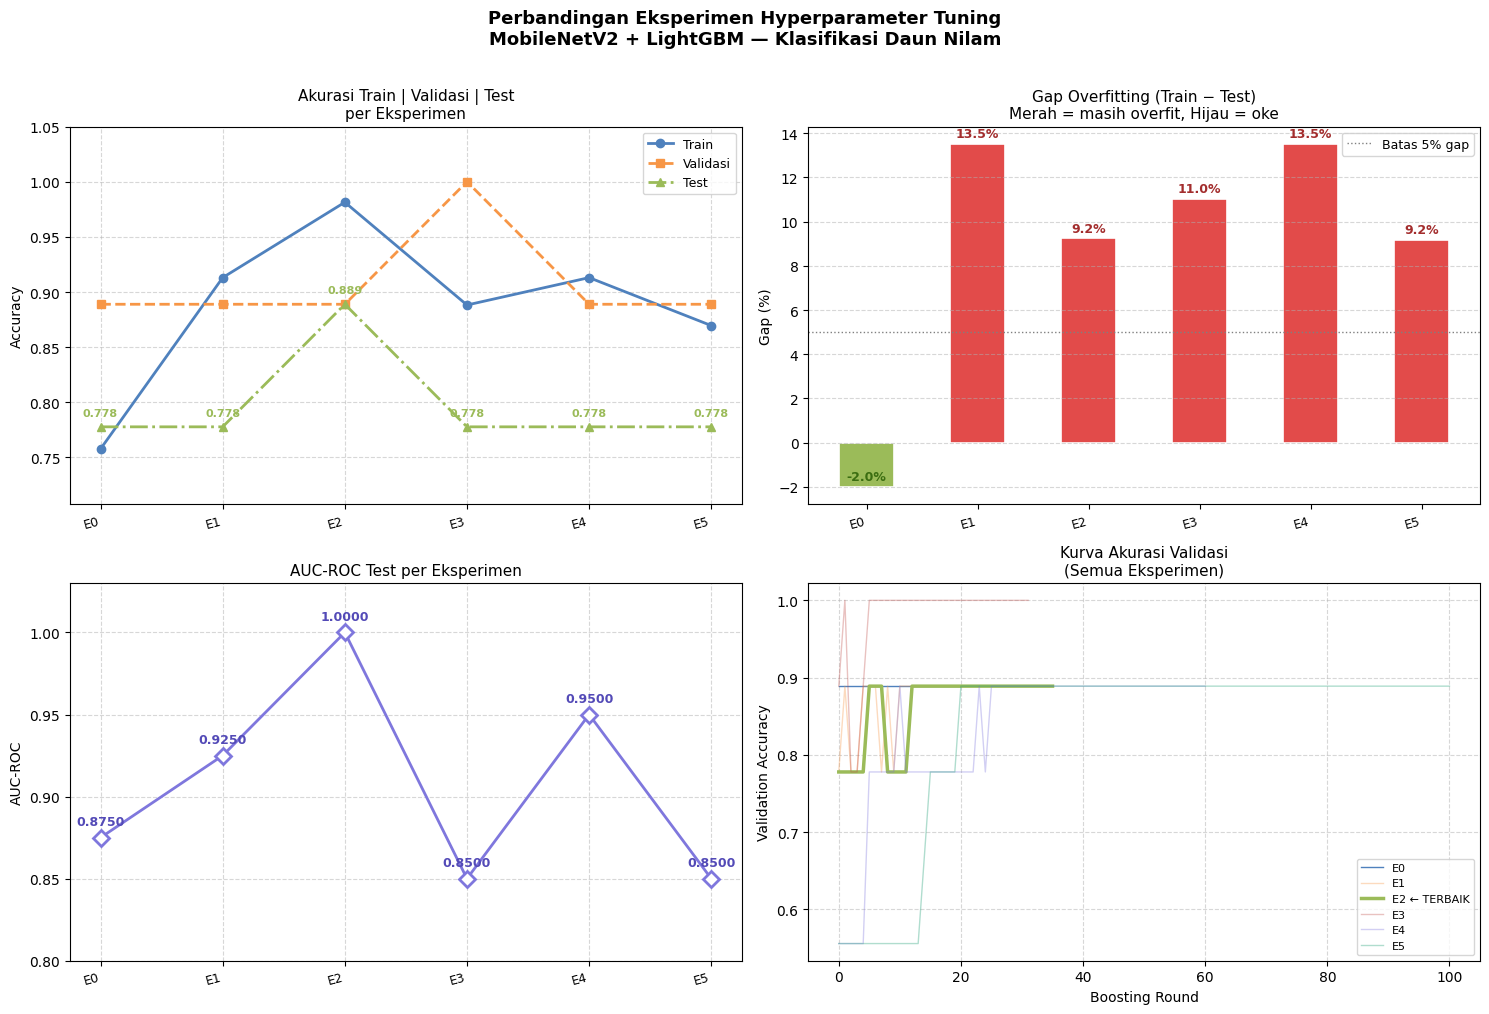

Grafik tersimpan: tuning_comparison.png


In [99]:
n_exp    = len(experiment_results)
names    = [r['name'] for r in experiment_results]
short_names = [r['name'].split('—')[0].strip() for r in experiment_results]

tr_accs  = [r['acc_train'] for r in experiment_results]
val_accs = [r['acc_val']   for r in experiment_results]
te_accs  = [r['acc_test']  for r in experiment_results]
gaps     = [r['gap']       for r in experiment_results]
aucs     = [r['auc_test']  for r in experiment_results]

x = range(n_exp)
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# ── Panel 1: Akurasi Train | Val | Test per eksperimen ──────────────
ax1 = axes[0, 0]
ax1.plot(x, tr_accs,  marker='o', linewidth=2, label='Train',    color='#4F81BD')
ax1.plot(x, val_accs, marker='s', linewidth=2, label='Validasi', color='#F79646', linestyle='--')
ax1.plot(x, te_accs,  marker='^', linewidth=2, label='Test',     color='#9BBB59', linestyle='-.')
for xi, (tr, va, te) in enumerate(zip(tr_accs, val_accs, te_accs)):
    ax1.annotate(f'{te:.3f}', (xi, te),
                 textcoords='offset points', xytext=(0, 8),
                 ha='center', fontsize=8, color='#9BBB59', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(short_names, rotation=15, ha='right', fontsize=9)
ax1.set_ylim(min(min(tr_accs), min(te_accs)) - 0.05, 1.05)
ax1.set_title('Akurasi Train | Validasi | Test\nper Eksperimen', fontsize=11)
ax1.set_ylabel('Accuracy')
ax1.legend(fontsize=9)
ax1.grid(True, linestyle='--', alpha=0.5)

# ── Panel 2: Gap Train–Test per eksperimen ──────────────────────────
ax2 = axes[0, 1]
bar_colors = ['#E24B4A' if g > 0.05 else '#9BBB59' for g in gaps]
bars2 = ax2.bar(x, [g * 100 for g in gaps], color=bar_colors,
                edgecolor='white', linewidth=1.2, width=0.5)
for bar, g in zip(bars2, gaps):
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{g*100:.1f}%',
        ha='center', fontsize=9, fontweight='bold',
        color='#A32D2D' if g > 0.05 else '#3B6D11'
    )
ax2.axhline(y=5, color='gray', linewidth=1, linestyle=':', label='Batas 5% gap')
ax2.set_xticks(x)
ax2.set_xticklabels(short_names, rotation=15, ha='right', fontsize=9)
ax2.set_title('Gap Overfitting (Train − Test)\nMerah = masih overfit, Hijau = oke', fontsize=11)
ax2.set_ylabel('Gap (%)')
ax2.legend(fontsize=9)
ax2.grid(axis='y', linestyle='--', alpha=0.5)

# ── Panel 3: AUC Test per eksperimen ────────────────────────────────
ax3 = axes[1, 0]
ax3.plot(x, aucs, marker='D', linewidth=2, color='#7F77DD',
         markersize=8, markerfacecolor='white', markeredgewidth=2)
for xi, auc in enumerate(aucs):
    ax3.annotate(f'{auc:.4f}', (xi, auc),
                 textcoords='offset points', xytext=(0, 9),
                 ha='center', fontsize=9, color='#534AB7', fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(short_names, rotation=15, ha='right', fontsize=9)
ax3.set_ylim(min(aucs) - 0.05, 1.03)
ax3.set_title('AUC-ROC Test per Eksperimen', fontsize=11)
ax3.set_ylabel('AUC-ROC')
ax3.grid(True, linestyle='--', alpha=0.5)

# ── Panel 4: Kurva validasi terbaik vs baseline ─────────────────────
ax4 = axes[1, 1]
best_idx = max(range(n_exp), key=lambda i: experiment_results[i]['acc_test'])
palette  = ['#4F81BD','#F79646','#9BBB59','#C0504D','#7F77DD','#1D9E75']
for i, r in enumerate(experiment_results):
    lw    = 2.5 if i == best_idx else 1
    alpha = 1.0 if i == best_idx or i == 0 else 0.35
    label = r['name'].split('—')[0].strip() + (' ← TERBAIK' if i == best_idx else '')
    ax4.plot(r['valid_curve'], linewidth=lw, alpha=alpha,
             color=palette[i % len(palette)], label=label)
ax4.set_title('Kurva Akurasi Validasi\n(Semua Eksperimen)', fontsize=11)
ax4.set_xlabel('Boosting Round')
ax4.set_ylabel('Validation Accuracy')
ax4.legend(fontsize=8, loc='lower right')
ax4.grid(True, linestyle='--', alpha=0.5)

plt.suptitle(
    'Perbandingan Eksperimen Hyperparameter Tuning\nMobileNetV2 + LightGBM — Klasifikasi Daun Nilam',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.savefig('tuning_comparison.png', dpi=10, bbox_inches='tight')
plt.show()
print("Grafik tersimpan: tuning_comparison.png")


In [100]:
model_map = {
    result_e0['name']: model_e0,
    result_e1['name']: model_e1,
    result_e2['name']: model_e2,
    result_e3['name']: model_e3,
    result_e4['name']: model_e4,
    result_e5['name']: model_e5,
}

best_result = max(experiment_results, key=lambda x: x['acc_test'])
best_model  = model_map[best_result['name']]

best_model.save_model('nilam_lgbm_best.txt')
print(f"Model terbaik disimpan sebagai: nilam_lgbm_best.txt")
print(f"Eksperimen : {best_result['name']}")
print(f"Acc Test   : {best_result['acc_test']:.4f}")
print(f"AUC Test   : {best_result['auc_test']:.4f}")
print(f"Best Round : {best_result['best_round']}")
print()
print("Parameter terbaik:")
exclude_keys = {'objective', 'metric', 'verbosity', 'seed'}
for k, v in best_result['params'].items():
    if k not in exclude_keys:
        print(f"  {k}: {v}")


Model terbaik disimpan sebagai: nilam_lgbm_best.txt
Eksperimen : E2 — Regularisasi L1 & L2
Acc Test   : 0.8889
AUC Test   : 1.0000
Best Round : 6

Parameter terbaik:
  num_leaves: 15
  max_depth: 5
  min_child_samples: 10
  lambda_l1: 0.1
  lambda_l2: 1.0


# Evaluasi Detail — E2 (Model Terbaik)

## Confusion Matrix — E2

=== Confusion Matrix E2 ===
TN=4  FP=1
FN=0  TP=4

Sensitivity (Recall kelas positif) : 1.0000
Specificity (Recall kelas negatif) : 0.8000

              precision    recall  f1-score   support

     nilamHT       1.00      0.80      0.89         5
     nilamSK       0.80      1.00      0.89         4

    accuracy                           0.89         9
   macro avg       0.90      0.90      0.89         9
weighted avg       0.91      0.89      0.89         9



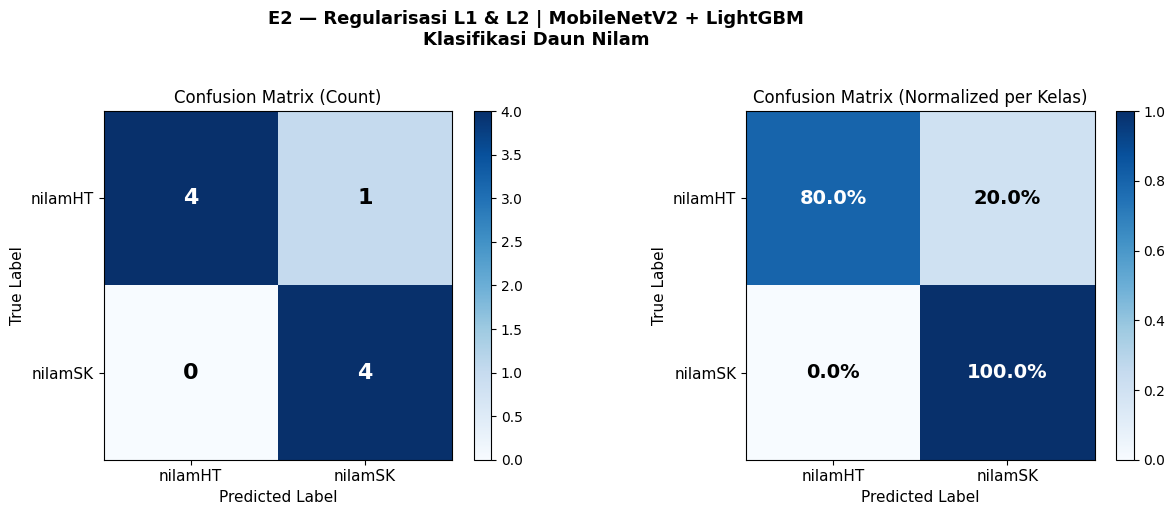

Grafik tersimpan: e2_confusion_matrix.png


In [101]:
# Prediksi ulang menggunakan model_e2
pred_prob_e2 = model_e2.predict(X_test_feat)
pred_lbl_e2  = (pred_prob_e2 >= 0.5).astype(int)

cm_e2 = confusion_matrix(y_test, pred_lbl_e2)
class_labels = le.classes_   # nama kelas asli (bukan angka)

# Hitung metrik per kelas
tn, fp, fn, tp = cm_e2.ravel()
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0  # recall kelas positif
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # recall kelas negatif

print("=== Confusion Matrix E2 ===")
print(f"TN={tn}  FP={fp}")
print(f"FN={fn}  TP={tp}")
print(f"\nSensitivity (Recall kelas positif) : {sensitivity:.4f}")
print(f"Specificity (Recall kelas negatif) : {specificity:.4f}")
print()
print(classification_report(y_test, pred_lbl_e2, target_names=class_labels))

# ── Plot Confusion Matrix ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Panel kiri: raw count ---
ax_l = axes[0]
im_l = ax_l.imshow(cm_e2, interpolation='nearest', cmap='Blues')
plt.colorbar(im_l, ax=ax_l, fraction=0.046, pad=0.04)
thresh = cm_e2.max() / 2.0
for i in range(2):
    for j in range(2):
        ax_l.text(j, i, str(cm_e2[i, j]),
                  ha='center', va='center', fontsize=16, fontweight='bold',
                  color='white' if cm_e2[i, j] > thresh else 'black')
ax_l.set_xticks([0, 1])
ax_l.set_yticks([0, 1])
ax_l.set_xticklabels(class_labels, fontsize=11)
ax_l.set_yticklabels(class_labels, fontsize=11)
ax_l.set_xlabel('Predicted Label', fontsize=11)
ax_l.set_ylabel('True Label', fontsize=11)
ax_l.set_title('Confusion Matrix (Count)', fontsize=12)

# --- Panel kanan: normalized (persentase per baris) ---
cm_norm = cm_e2.astype('float') / cm_e2.sum(axis=1, keepdims=True)
ax_r = axes[1]
im_r = ax_r.imshow(cm_norm, interpolation='nearest', cmap='Blues', vmin=0, vmax=1)
plt.colorbar(im_r, ax=ax_r, fraction=0.046, pad=0.04)
thresh_n = 0.5
for i in range(2):
    for j in range(2):
        ax_r.text(j, i,
                  f'{cm_norm[i, j]*100:.1f}%',
                  ha='center', va='center', fontsize=14, fontweight='bold',
                  color='white' if cm_norm[i, j] > thresh_n else 'black')
ax_r.set_xticks([0, 1])
ax_r.set_yticks([0, 1])
ax_r.set_xticklabels(class_labels, fontsize=11)
ax_r.set_yticklabels(class_labels, fontsize=11)
ax_r.set_xlabel('Predicted Label', fontsize=11)
ax_r.set_ylabel('True Label', fontsize=11)
ax_r.set_title('Confusion Matrix (Normalized per Kelas)', fontsize=12)

plt.suptitle(
    'E2 — Regularisasi L1 & L2 | MobileNetV2 + LightGBM\nKlasifikasi Daun Nilam',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('e2_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik tersimpan: e2_confusion_matrix.png")


## Top 20 Feature Importance (Gain) — E2

Total fitur aktif (gain > 0): 16 dari 1280

Rank  Feature              Gain   Gain %   Split
------------------------------------------------
1     Feature_53         270.99   57.65%       6
2     Feature_997         51.34   10.92%       4
3     Feature_264         36.44    7.75%       3
4     Feature_181         29.76    6.33%       2
5     Feature_427         18.69    3.98%       2
6     Feature_1028        17.92    3.81%       2
7     Feature_318         14.98    3.19%       2
8     Feature_1226         9.49    2.02%       2
9     Feature_376          7.89    1.68%       1
10    Feature_446          3.11    0.66%       1
11    Feature_207          2.27    0.48%       1
12    Feature_179          2.16    0.46%       1
13    Feature_889          1.59    0.34%       1
14    Feature_1007         1.51    0.32%       1
15    Feature_172          1.39    0.30%       1
16    Feature_1080         0.53    0.11%       1
17    Feature_5            0.00    0.00%       0
18    Feature_4          

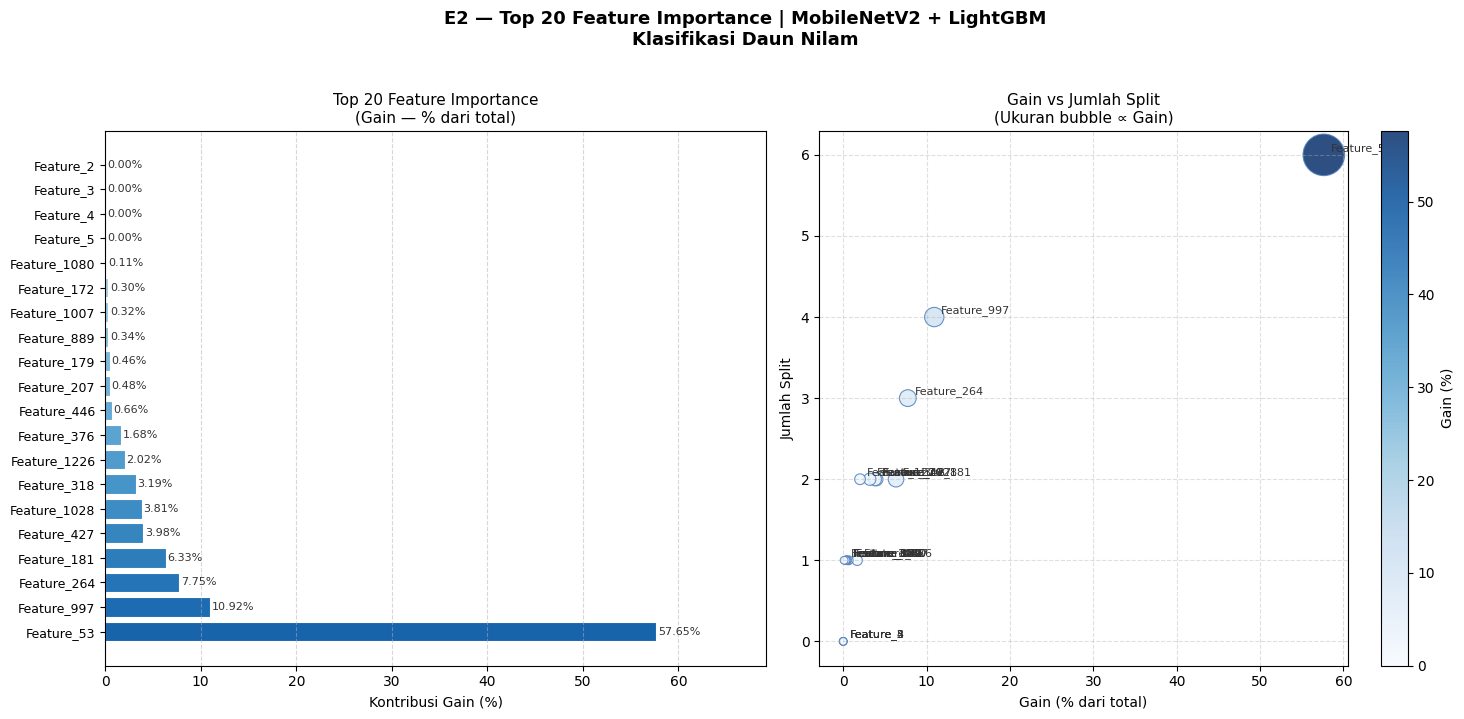

Grafik tersimpan: e2_feature_importance.png

Konsentrasi gain:
  Top 5  fitur = 86.6% dari total gain
  Top 10 fitur = 98.0% dari total gain
  Top 20 fitur = 100.0% dari total gain


In [ ]:
importance_gain  = model_e2.feature_importance(importance_type='gain')
importance_split = model_e2.feature_importance(importance_type='split')
n_features       = len(importance_gain)
feature_names    = [f'Feature_{i}' for i in range(n_features)]

top_n   = 20
top_idx = np.argsort(importance_gain)[::-1][:top_n]

top_names  = [feature_names[i] for i in top_idx]
top_gain   = importance_gain[top_idx]
top_split  = importance_split[top_idx]

total_gain    = importance_gain.sum()
top_gain_pct  = (top_gain / total_gain * 100) if total_gain > 0 else top_gain

# Cetak tabel
print(f"Total fitur aktif (gain > 0): {(importance_gain > 0).sum()} dari {n_features}")
print(f"\n{'Rank':<5} {'Feature':<12} {'Gain':>12} {'Gain %':>8} {'Split':>7}")
print('-' * 48)
for rank, (nm, g, gp, sp) in enumerate(
        zip(top_names, top_gain, top_gain_pct, top_split), 1):
    print(f"{rank:<5} {nm:<12} {g:>12.2f} {gp:>7.2f}% {sp:>7}")

# ── Plot ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# --- Panel kiri: Gain (bar horizontal) ---
ax1 = axes[0]
colors_gain = plt.cm.Blues_r(
    np.linspace(0.2, 0.8, top_n)
)[::-1]   # gradasi biru gelap → terang

y_pos = range(top_n - 1, -1, -1)   # urutan terbalik agar rank 1 di atas
bars1 = ax1.barh(
    list(y_pos),
    top_gain_pct[::-1],
    color=colors_gain,
    edgecolor='white', linewidth=0.8
)
ax1.set_yticks(list(y_pos))
ax1.set_yticklabels(top_names[::-1], fontsize=9)

for bar, pct in zip(bars1, top_gain_pct[::-1]):
    ax1.text(
        bar.get_width() + 0.2,
        bar.get_y() + bar.get_height() / 2,
        f'{pct:.2f}%',
        va='center', fontsize=8, color='#333'
    )

ax1.set_xlabel('Kontribusi Gain (%)', fontsize=10)
ax1.set_title('Top 20 Feature Importance\n(Gain — % dari total)', fontsize=11)
ax1.grid(axis='x', linestyle='--', alpha=0.5)
ax1.set_xlim(0, top_gain_pct.max() * 1.2)

# --- Panel kanan: Split count (bubble/dot chart) ---
ax2 = axes[1]
scatter = ax2.scatter(
    top_gain_pct,
    top_split,
    c=top_gain_pct,
    cmap='Blues',
    s=top_gain_pct * 15 + 30,   # ukuran bubble proporsional dengan gain
    alpha=0.85,
    edgecolors='#4F81BD',
    linewidths=0.8
)
plt.colorbar(scatter, ax=ax2, label='Gain (%)')

for nm, gp, sp in zip(top_names, top_gain_pct, top_split):
    ax2.annotate(
        nm,
        (gp, sp),
        textcoords='offset points',
        xytext=(5, 3),
        fontsize=8,
        color='#333'
    )

ax2.set_xlabel('Gain (% dari total)', fontsize=10)
ax2.set_ylabel('Jumlah Split', fontsize=10)
ax2.set_title('Gain vs Jumlah Split\n(Ukuran bubble ∝ Gain)', fontsize=11)
ax2.grid(True, linestyle='--', alpha=0.4)

plt.suptitle(
    'E2 — Top 20 Feature Importance | MobileNetV2 + LightGBM\nKlasifikasi Daun Nilam',
    fontsize=13, fontweight='bold', y=1.02
)
plt.tight_layout()
plt.savefig('e2_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Grafik tersimpan: e2_feature_importance.png")

# Ringkasan konsentrasi
top5_pct  = top_gain_pct[:5].sum()
top10_pct = top_gain_pct[:10].sum()
print(f"\nKonsentrasi gain:")
print(f"  Top 5  fitur = {top5_pct:.1f}% dari total gain")
print(f"  Top 10 fitur = {top10_pct:.1f}% dari total gain")
print(f"  Top 20 fitur = {top_gain_pct.sum():.1f}% dari total gain")
